# Comparação de Modelos de Regressão Não Linear
## Previsão do Tempo de Entrega de Pedidos

Este é o notebook mais avançado da série. Vamos enfrentar um problema realista de logística: **prever o tempo de entrega (em minutos) de um pedido**, dadas características da rota, do veículo, do entregador e da operação.

Comparare**mos quatro modelos** clássicos de regressão não linear:

1. **Regressão Polinomial** (linear + features de grau 2)
2. **Random Forest** (ensemble de árvores por bagging)
3. **XGBoost** (gradient boosting)
4. **CatBoost** (gradient boosting com tratamento nativo de categóricas)

Esse problema é interessante porque combina:
- **Variáveis numéricas** (distância, peso, experiência…)
- **Variáveis categóricas** (tipo de veículo, clima, dia da semana…)
- **Não linearidades fortes** (horários de pico, efeitos do clima, retorno decrescente da experiência)
- **Interações** (peso × tipo de veículo, distância × trânsito × clima)

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Carregamento e Visão Geral dos Dados

O dataset traz 1.200 pedidos de entrega com 9 variáveis explicativas e o tempo total de entrega em minutos.

In [2]:
df = pd.read_csv('dados_entregas.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 1200 linhas × 10 colunas


,distancia_km,peso_kg,num_paradas,hora_do_dia,dia_semana,tipo_veiculo,clima,experiencia_motorista_anos,transito_index,tempo_entrega_min
0,7.09,22.83,3,9,5,3,1,0.1,9,43.96
1,36.48,22.04,3,21,3,3,1,17.1,3,43.73
2,9.44,3.75,1,11,6,2,3,17.3,1,5.00
3,39.78,10.42,7,19,3,3,2,1.9,6,134.74
4,24.59,18.70,6,21,3,3,3,3.0,8,100.26
5,4.29,7.95,7,7,2,1,4,9.0,9,33.14
6,3.55,16.65,3,11,2,1,1,3.7,2,15.04
7,3.92,6.08,4,15,5,3,3,14.7,4,11.85
8,24.01,8.22,4,20,4,1,3,1.2,8,101.00
9,32.57,21.54,4,9,5,3,2,11.0,1,17.71


In [3]:
df.describe().round(2)

,distancia_km,peso_kg,num_paradas,hora_do_dia,dia_semana,tipo_veiculo,clima,experiencia_motorista_anos,transito_index,tempo_entrega_min
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,19.69,12.46,4.02,13.95,4.06,1.98,2.46,9.95,5.54,50.13
std,11.08,7.16,1.99,4.90,1.99,0.82,1.13,5.81,2.89,37.92
min,1.01,0.21,1.00,6.00,1.00,1.00,1.00,0.00,1.00,5.00
25%,10.18,6.28,2.00,10.00,2.00,1.00,1.00,4.80,3.00,22.15
50%,19.07,12.60,4.00,14.00,4.00,2.00,2.00,10.05,6.00,40.22
75%,29.24,18.70,6.00,18.00,6.00,3.00,3.00,15.00,8.00,67.28
max,39.99,24.99,7.00,22.00,7.00,3.00,4.00,20.00,10.00,274.80


### Dicionário de Dados

| Variável | Descrição | Tipo |
|---|---|---|
| `distancia_km` | Distância da rota | numérica |
| `peso_kg` | Peso total do pedido | numérica |
| `num_paradas` | Paradas extras na rota | numérica |
| `hora_do_dia` | Hora de saída (0–23) | numérica |
| `dia_semana` | 1 = segunda … 7 = domingo | categórica |
| `tipo_veiculo` | 1 = moto, 2 = carro, 3 = van | categórica |
| `clima` | 1 = sol, 2 = nublado, 3 = chuva, 4 = tempestade | categórica |
| `experiencia_motorista_anos` | Tempo de experiência | numérica |
| `transito_index` | Índice de trânsito 1–10 | numérica |
| `tempo_entrega_min` | **Alvo:** tempo total | numérica |

## 3. Análise Exploratória

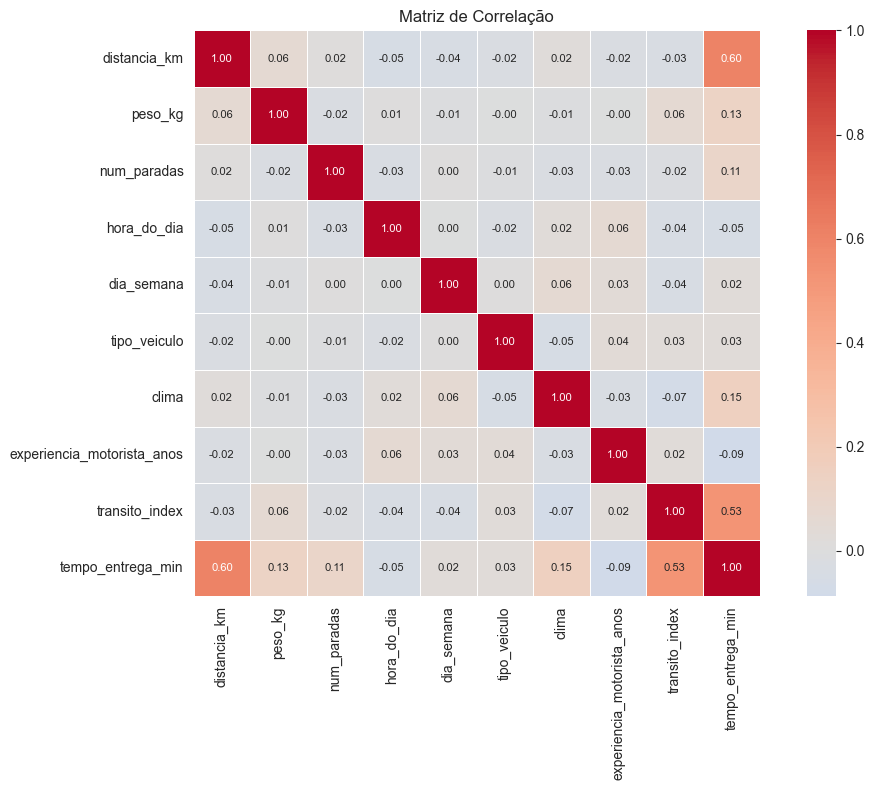

In [4]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

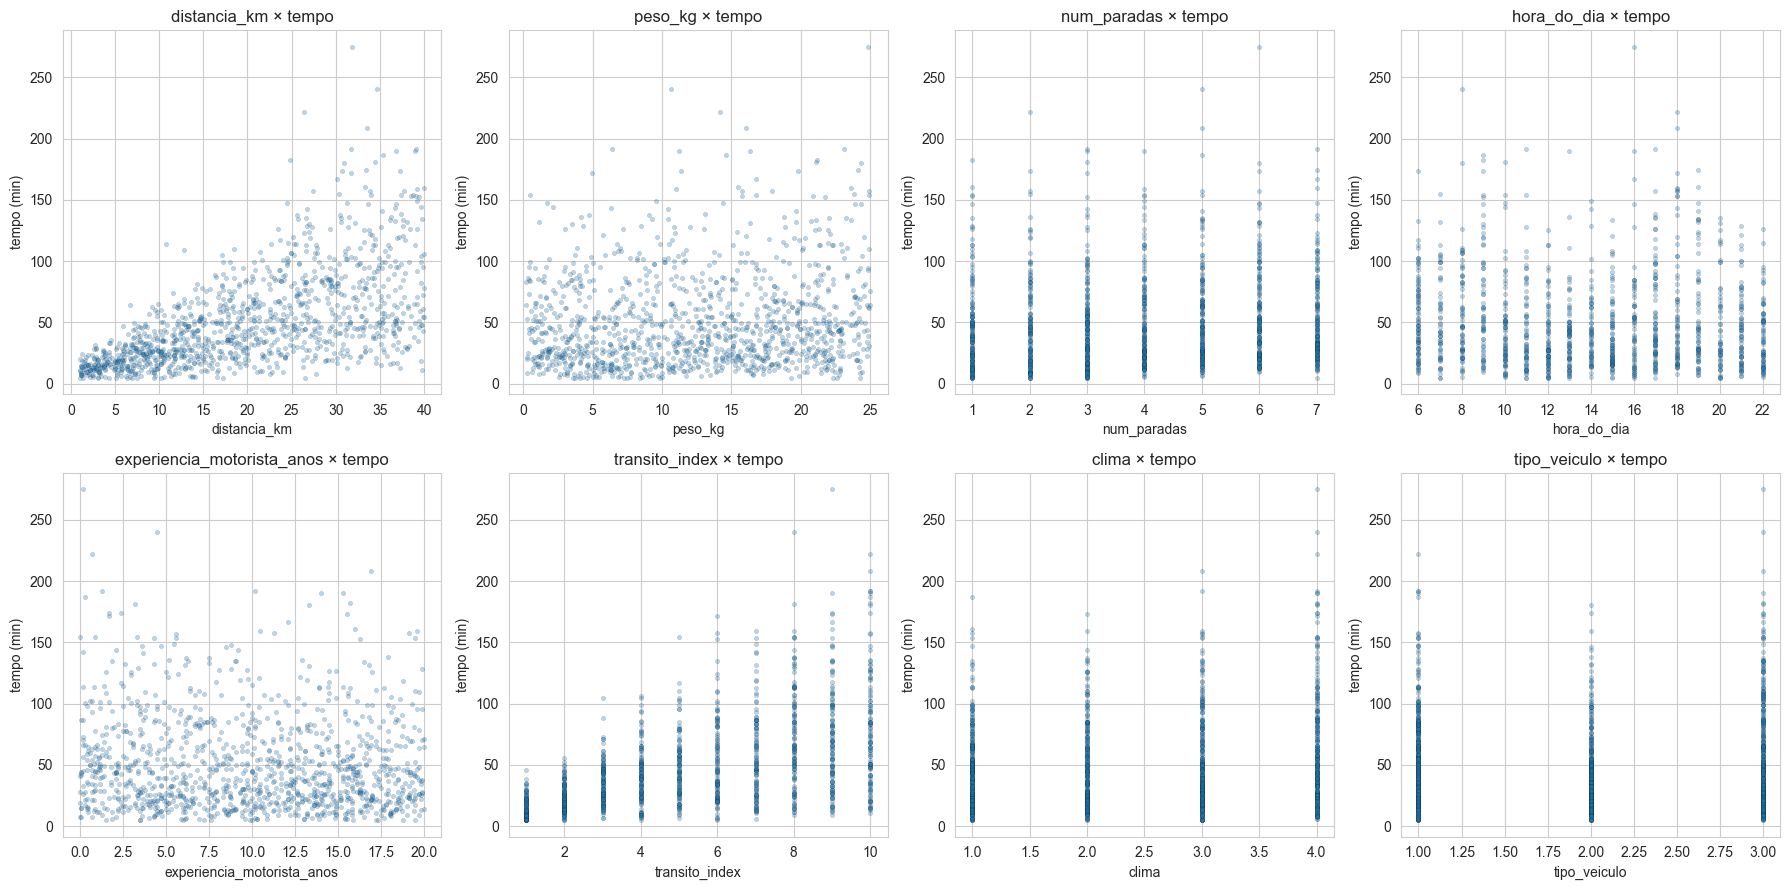

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
features_plot = ['distancia_km', 'peso_kg', 'num_paradas', 'hora_do_dia',
                 'experiencia_motorista_anos', 'transito_index', 'clima', 'tipo_veiculo']

for ax, col in zip(axes.flatten(), features_plot):
    ax.scatter(df[col], df['tempo_entrega_min'], alpha=0.3, s=10,
               edgecolors='k', linewidths=0.2)
    ax.set_xlabel(col)
    ax.set_ylabel('tempo (min)')
    ax.set_title(f'{col} × tempo')

plt.tight_layout()
plt.show()

Note alguns padrões fortemente não lineares:
- **`hora_do_dia`** apresenta picos em volta das 8h e 18h (horários de pico).
- **`clima`** afeta o tempo de forma escalonada (categorias).
- **`distancia_km`** tem relação aproximadamente linear, mas dispersa por causa de interações com trânsito e clima.

## 4. Preparação dos Dados

In [6]:
X = df.drop(columns='tempo_entrega_min')
y = df['tempo_entrega_min']

# Lista das colunas categóricas (importante para o CatBoost)
cat_features = ['dia_semana', 'tipo_veiculo', 'clima']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 960 amostras
Teste:  240 amostras


## 5. Função Auxiliar de Avaliação

Para manter o código limpo, definimos uma função que retorna as métricas e o tempo de treino de cada modelo.

In [7]:
def avaliar(modelo, X_tr, y_tr, X_te, y_te, nome):
    inicio = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    tempo_fit = time.perf_counter() - inicio

    y_pred = modelo.predict(X_te)
    return {
        'Modelo': nome,
        'R²': r2_score(y_te, y_pred),
        'MAE': mean_absolute_error(y_te, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'Tempo (s)': tempo_fit,
        'y_pred': y_pred,
        'estimator': modelo,
    }

## 6. Modelo 1 — Regressão Polinomial (grau 2 + Ridge)

Para a regressão polinomial, criamos features de grau 2 e usamos **Ridge** (regularização L2) para evitar instabilidade numérica e sobreajuste com tantas features cruzadas. A padronização (`StandardScaler`) é importante aqui por causa das diferentes escalas das variáveis.

In [8]:
poly_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
    Ridge(alpha=1.0)
)

res_poly = avaliar(poly_pipe, X_treino, y_treino, X_teste, y_teste, 'Polinomial (grau 2)')

print(f"R²:    {res_poly['R²']:.4f}")
print(f"MAE:   {res_poly['MAE']:.2f} min")
print(f"RMSE:  {res_poly['RMSE']:.2f} min")
print(f"Tempo: {res_poly['Tempo (s)']:.3f} s")

R²:    0.8751
MAE:   9.68 min
RMSE:  14.87 min
Tempo: 0.002 s


## 7. Modelo 2 — Random Forest

O **Random Forest** treina muitas árvores em amostras aleatórias dos dados (bagging) e em cada split considera apenas um subconjunto aleatório das features. O resultado é a média das previsões de todas as árvores.

In [9]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

res_rf = avaliar(rf, X_treino, y_treino, X_teste, y_teste, 'Random Forest')

print(f"R²:    {res_rf['R²']:.4f}")
print(f"MAE:   {res_rf['MAE']:.2f} min")
print(f"RMSE:  {res_rf['RMSE']:.2f} min")
print(f"Tempo: {res_rf['Tempo (s)']:.3f} s")

R²:    0.8421
MAE:   10.31 min
RMSE:  16.71 min
Tempo: 0.163 s


## 8. Modelo 3 — XGBoost

In [10]:
xgb = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

res_xgb = avaliar(xgb, X_treino, y_treino, X_teste, y_teste, 'XGBoost')

print(f"R²:    {res_xgb['R²']:.4f}")
print(f"MAE:   {res_xgb['MAE']:.2f} min")
print(f"RMSE:  {res_xgb['RMSE']:.2f} min")
print(f"Tempo: {res_xgb['Tempo (s)']:.3f} s")

R²:    0.9028
MAE:   7.62 min
RMSE:  13.11 min
Tempo: 1.636 s


## 9. Modelo 4 — CatBoost

A grande diferença do CatBoost: ele aceita variáveis **categóricas** diretamente, sem necessidade de One-Hot Encoding ou Label Encoding. Basta indicar quais colunas são categóricas via `cat_features`.

In [11]:
cat = CatBoostRegressor(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    cat_features=cat_features,
    random_seed=42,
    verbose=0
)

res_cat = avaliar(cat, X_treino, y_treino, X_teste, y_teste, 'CatBoost')

print(f"R²:    {res_cat['R²']:.4f}")
print(f"MAE:   {res_cat['MAE']:.2f} min")
print(f"RMSE:  {res_cat['RMSE']:.2f} min")
print(f"Tempo: {res_cat['Tempo (s)']:.3f} s")

R²:    0.9364
MAE:   5.90 min
RMSE:  10.60 min
Tempo: 0.716 s


## 10. Comparação dos Modelos

In [12]:
resultados_lista = [res_poly, res_rf, res_xgb, res_cat]

df_resultados = pd.DataFrame([
    {k: r[k] for k in ['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo (s)']}
    for r in resultados_lista
]).set_index('Modelo')

df_resultados.round(4)

,R²,MAE,RMSE,Tempo (s)
Modelo,,,,
Polinomial (grau 2),0.8751,9.6775,14.8678,0.0019
Random Forest,0.8421,10.3137,16.7140,0.1626
XGBoost,0.9028,7.6168,13.1135,1.6356
CatBoost,0.9364,5.9035,10.6039,0.7155


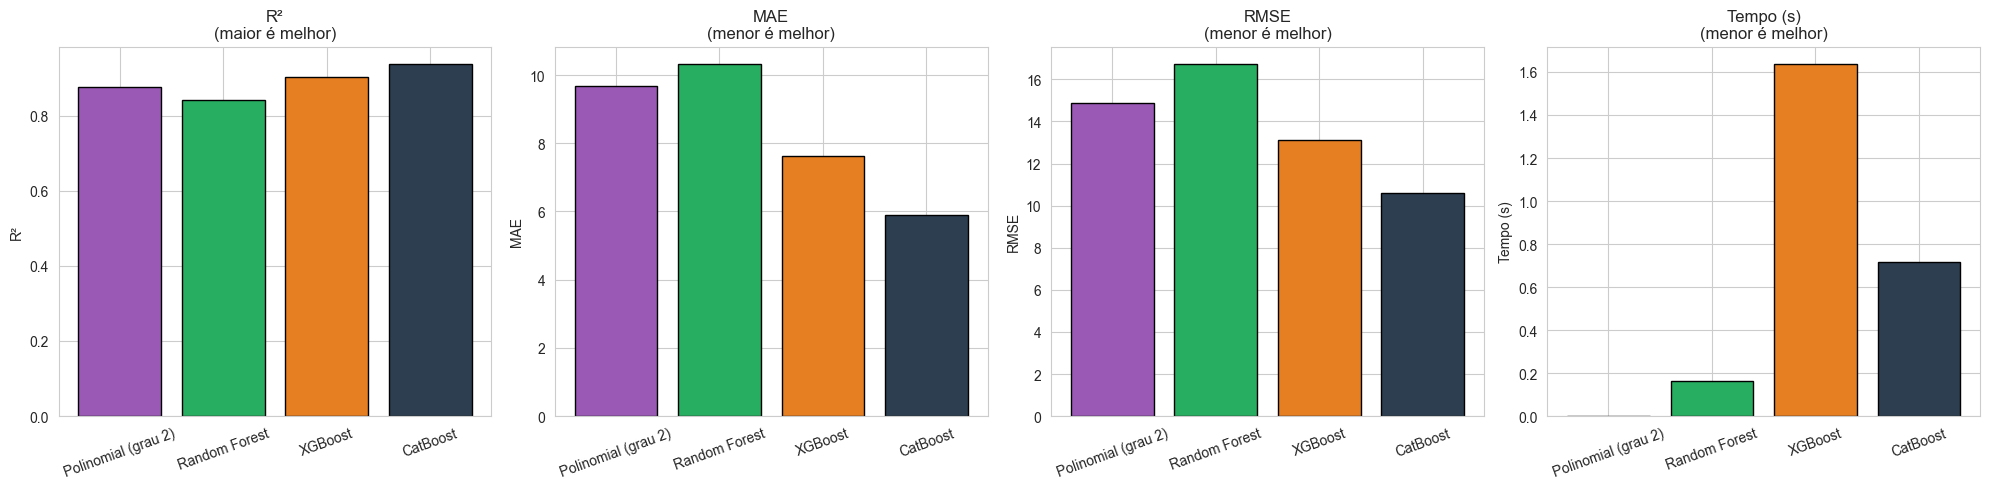

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metricas = [('R²', 'maior é melhor'),
            ('MAE', 'menor é melhor'),
            ('RMSE', 'menor é melhor'),
            ('Tempo (s)', 'menor é melhor')]
cores = ['#9b59b6', '#27ae60', '#e67e22', '#2c3e50']

for ax, (m, leg) in zip(axes, metricas):
    valores = df_resultados[m].values
    ax.bar(df_resultados.index, valores, color=cores, edgecolor='black')
    ax.set_title(f'{m}\n({leg})')
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 11. Validação Cruzada (5-Fold)

Para uma comparação mais robusta, avaliamos cada modelo via 5-fold cross-validation.

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelos que funcionam direto com cross_val_score do scikit-learn
modelos_cv = {
    'Polinomial (grau 2)': make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        Ridge(alpha=1.0)
    ),
    'Random Forest': RandomForestRegressor(n_estimators=400, min_samples_leaf=3,
                                           n_jobs=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.05,
                            subsample=0.9, colsample_bytree=0.9,
                            random_state=42, n_jobs=-1),
}

cv_resultados = []
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_treino, y_treino, cv=kf,
                             scoring='r2', n_jobs=1)
    cv_resultados.append({
        'Modelo': nome,
        'R² Médio': scores.mean(),
        'Desvio Padrão': scores.std(),
    })
    print(f'  {nome:<22s}  R² = {scores.mean():.4f} ± {scores.std():.4f}')

# CatBoost com cat_features tem incompatibilidade com o clone() do scikit-learn,
# então fazemos o loop de validação cruzada manualmente.
scores_cat = []
for tr_idx, te_idx in kf.split(X_treino):
    X_tr, X_te = X_treino.iloc[tr_idx], X_treino.iloc[te_idx]
    y_tr, y_te = y_treino.iloc[tr_idx], y_treino.iloc[te_idx]
    m = CatBoostRegressor(iterations=800, depth=6, learning_rate=0.05,
                          cat_features=cat_features, random_seed=42, verbose=0)
    m.fit(X_tr, y_tr)
    scores_cat.append(r2_score(y_te, m.predict(X_te)))

scores_cat = np.array(scores_cat)
cv_resultados.append({
    'Modelo': 'CatBoost',
    'R² Médio': scores_cat.mean(),
    'Desvio Padrão': scores_cat.std(),
})
print(f'  {"CatBoost":<22s}  R² = {scores_cat.mean():.4f} ± {scores_cat.std():.4f}')

pd.DataFrame(cv_resultados).round(4)

  Polinomial (grau 2)     R² = 0.8892 ± 0.0056


  Random Forest           R² = 0.8447 ± 0.0118


  XGBoost                 R² = 0.9128 ± 0.0163


  CatBoost                R² = 0.9455 ± 0.0055


,Modelo,R² Médio,Desvio Padrão
0,Polinomial (grau 2),0.8892,0.0056
1,Random Forest,0.8447,0.0118
2,XGBoost,0.9128,0.0163
3,CatBoost,0.9455,0.0055


## 12. Valores Reais vs Previstos

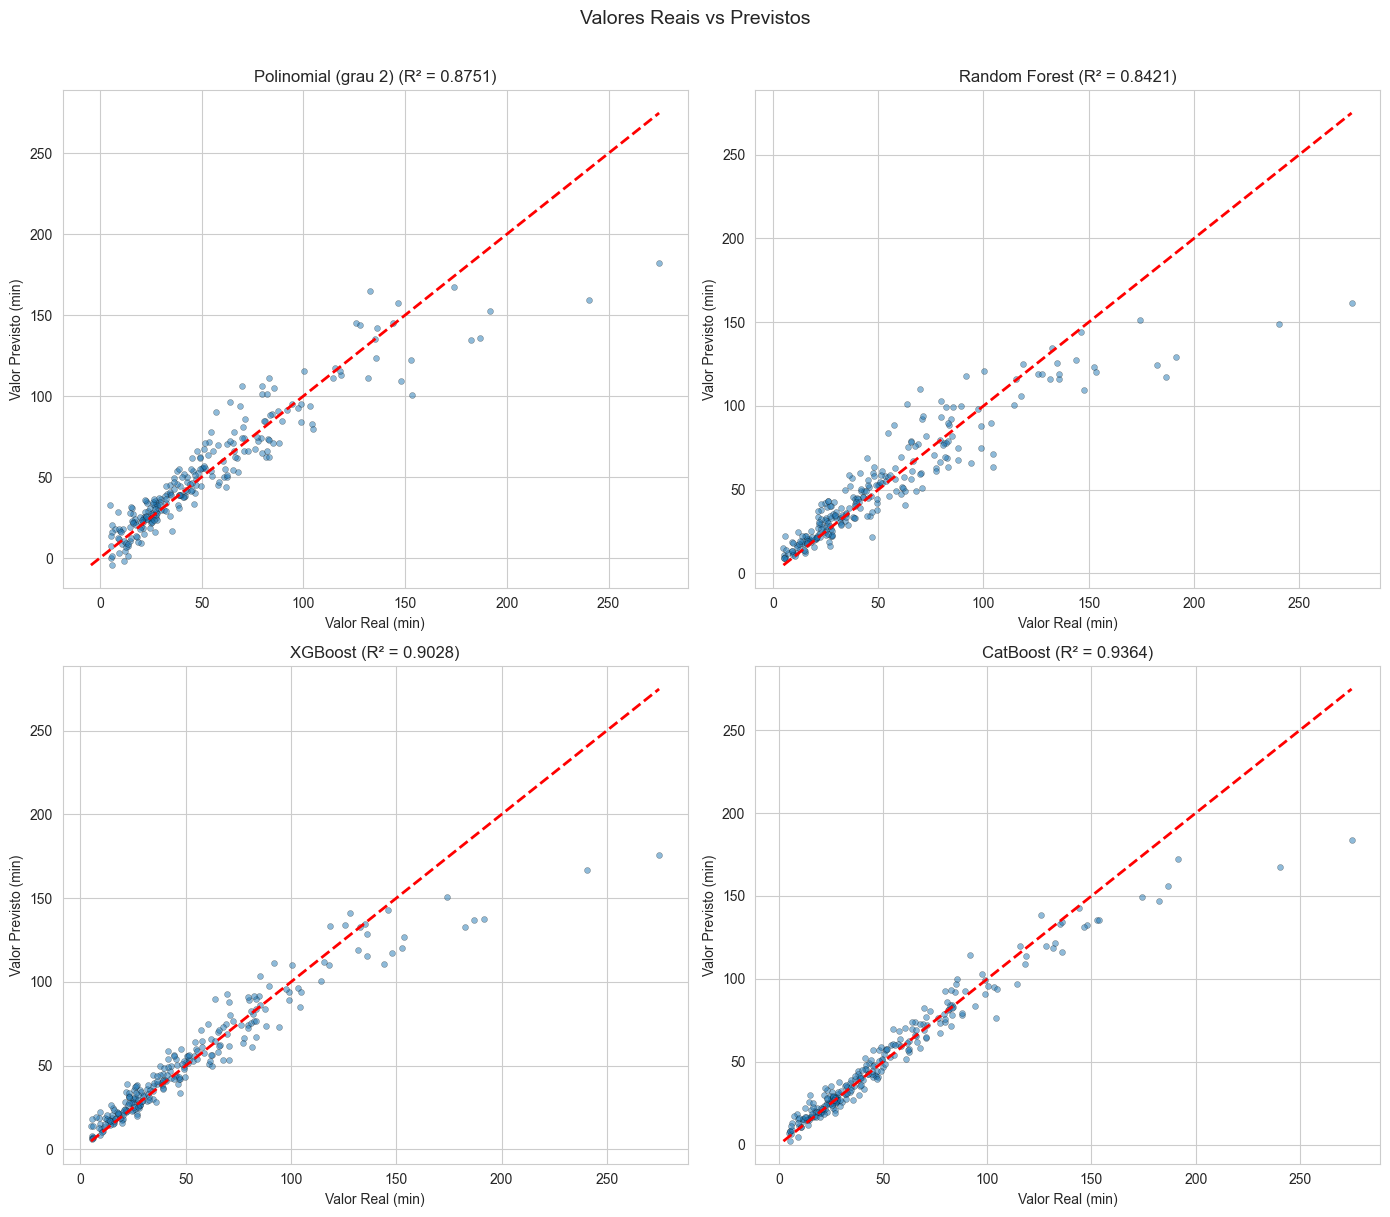

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, r in zip(axes.flatten(), resultados_lista):
    ax.scatter(y_teste, r['y_pred'], alpha=0.5, s=18,
               edgecolors='k', linewidths=0.3)
    lims = [min(y_teste.min(), r['y_pred'].min()),
            max(y_teste.max(), r['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_xlabel('Valor Real (min)')
    ax.set_ylabel('Valor Previsto (min)')
    ax.set_title(f"{r['Modelo']} (R² = {r['R²']:.4f})")

plt.suptitle('Valores Reais vs Previstos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 13. Análise de Resíduos

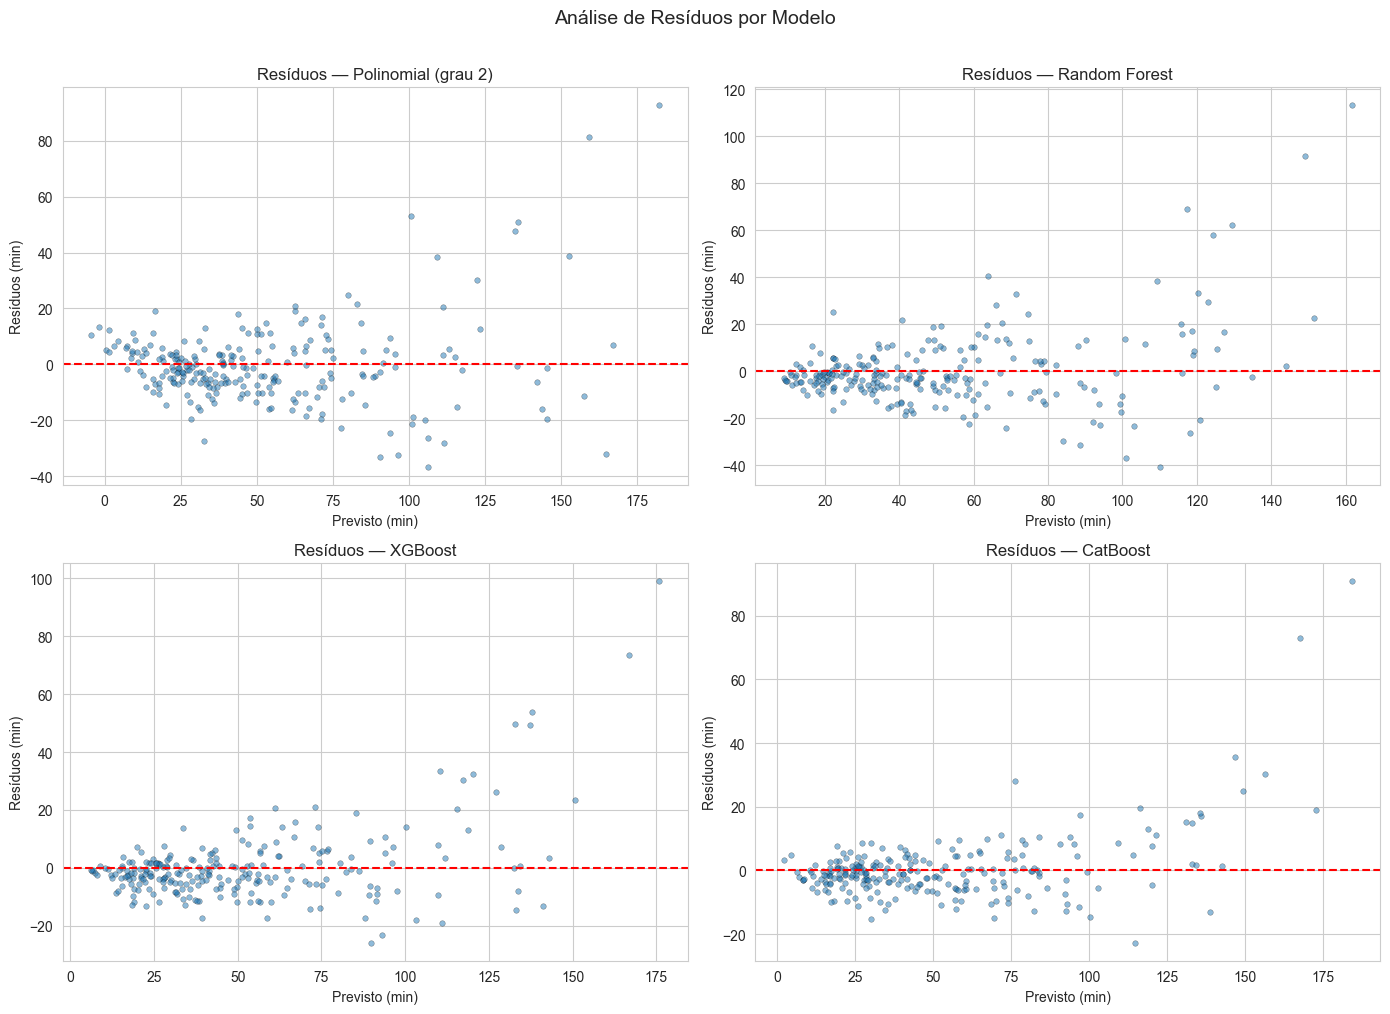

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, r in zip(axes.flatten(), resultados_lista):
    residuos = y_teste - r['y_pred']
    ax.scatter(r['y_pred'], residuos, alpha=0.5, s=16, edgecolors='k', linewidths=0.3)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Previsto (min)')
    ax.set_ylabel('Resíduos (min)')
    ax.set_title(f"Resíduos — {r['Modelo']}")

plt.suptitle('Análise de Resíduos por Modelo', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 14. Importância de Variáveis (modelos baseados em árvore)

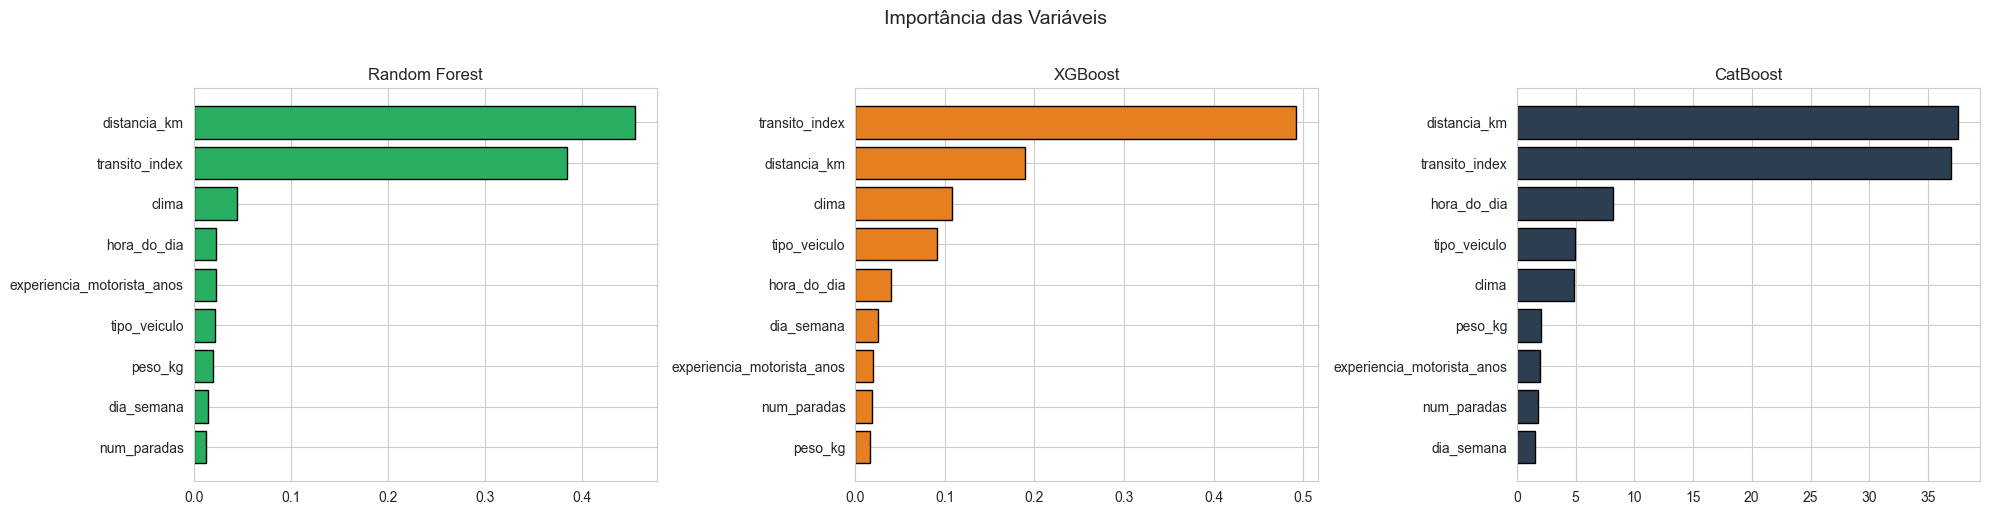

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Random Forest
imp_rf = pd.DataFrame({
    'Variável': X.columns,
    'Importância': res_rf['estimator'].feature_importances_
}).sort_values('Importância', ascending=True)
axes[0].barh(imp_rf['Variável'], imp_rf['Importância'], color='#27ae60', edgecolor='black')
axes[0].set_title('Random Forest')

# XGBoost
imp_xgb = pd.DataFrame({
    'Variável': X.columns,
    'Importância': res_xgb['estimator'].feature_importances_
}).sort_values('Importância', ascending=True)
axes[1].barh(imp_xgb['Variável'], imp_xgb['Importância'], color='#e67e22', edgecolor='black')
axes[1].set_title('XGBoost')

# CatBoost
imp_cat = pd.DataFrame({
    'Variável': X.columns,
    'Importância': res_cat['estimator'].get_feature_importance()
}).sort_values('Importância', ascending=True)
axes[2].barh(imp_cat['Variável'], imp_cat['Importância'], color='#2c3e50', edgecolor='black')
axes[2].set_title('CatBoost')

plt.suptitle('Importância das Variáveis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Os três modelos baseados em árvore concordam, em geral, sobre quais variáveis são mais relevantes — costumam aparecer no topo a `distancia_km`, o `transito_index`, o `clima` e o `tipo_veiculo`. Isso dá confiança no diagnóstico das variáveis que guiam o tempo de entrega.

## 15. Distribuição dos Erros Absolutos

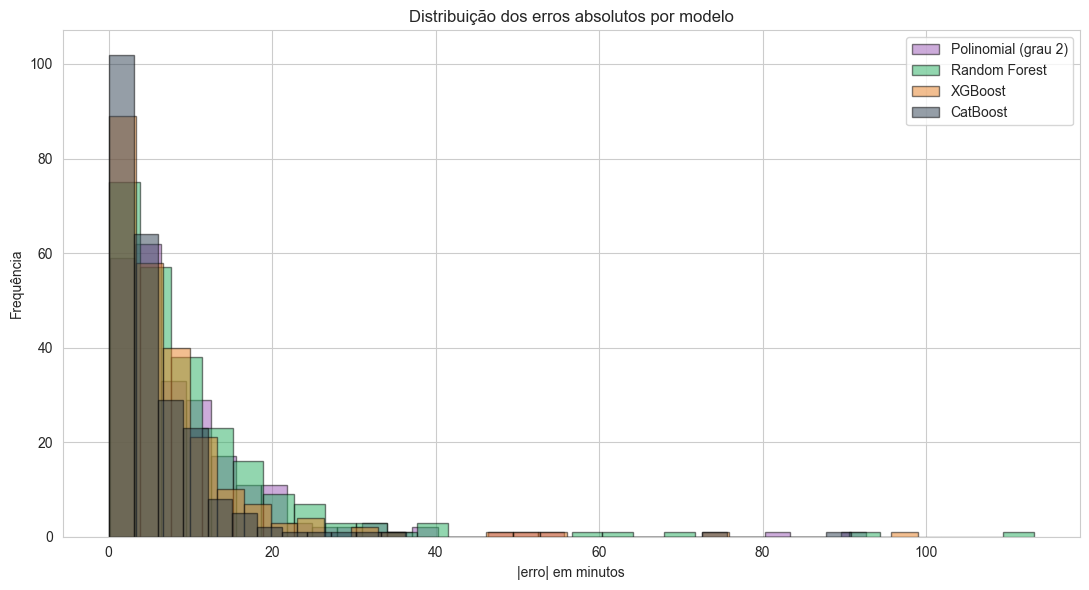

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

for r, c in zip(resultados_lista, ['#9b59b6', '#27ae60', '#e67e22', '#2c3e50']):
    erros = np.abs(y_teste - r['y_pred'])
    ax.hist(erros, bins=30, alpha=0.5, label=r['Modelo'], color=c, edgecolor='black')

ax.set_xlabel('|erro| em minutos')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição dos erros absolutos por modelo')
ax.legend()
plt.tight_layout()
plt.show()

## 16. Previsões em Novos Cenários

Vamos simular alguns pedidos novos e ver o que os modelos preveem.

In [19]:
novos_pedidos = pd.DataFrame([
    # Pedido fácil: pouca distância, sol, baixo trânsito, motorista experiente
    {'distancia_km': 3,  'peso_kg': 1.5, 'num_paradas': 1, 'hora_do_dia': 14,
     'dia_semana': 3, 'tipo_veiculo': 1, 'clima': 1,
     'experiencia_motorista_anos': 10, 'transito_index': 2},
    # Pedido difícil: longa distância, tempestade, hora de pico, motorista novato
    {'distancia_km': 28, 'peso_kg': 18, 'num_paradas': 5, 'hora_do_dia': 18,
     'dia_semana': 5, 'tipo_veiculo': 3, 'clima': 4,
     'experiencia_motorista_anos': 1, 'transito_index': 9},
    # Pedido intermediário
    {'distancia_km': 12, 'peso_kg': 6, 'num_paradas': 2, 'hora_do_dia': 11,
     'dia_semana': 2, 'tipo_veiculo': 2, 'clima': 2,
     'experiencia_motorista_anos': 5, 'transito_index': 5},
])

prev = pd.DataFrame({
    'Polinomial': res_poly['estimator'].predict(novos_pedidos),
    'Random Forest': res_rf['estimator'].predict(novos_pedidos),
    'XGBoost': res_xgb['estimator'].predict(novos_pedidos),
    'CatBoost': res_cat['estimator'].predict(novos_pedidos),
}).round(2)

resultado_pedidos = pd.concat([novos_pedidos.reset_index(drop=True), prev], axis=1)
resultado_pedidos

,distancia_km,peso_kg,num_paradas,hora_do_dia,dia_semana,tipo_veiculo,clima,experiencia_motorista_anos,transito_index,Polinomial,Random Forest,XGBoost,CatBoost
0,3,1.5,1,14,3,1,1,10,2,16.57,8.34,3.690000,2.57
1,28,18.0,5,18,5,3,4,1,9,154.40,146.34,176.009995,184.16
2,12,6.0,2,11,2,2,2,5,5,16.18,25.95,19.580000,11.84


## 17. Resumo Final

| Modelo | Pontos Fortes | Cuidados |
|---|---|---|
| **Polinomial** | Simples, rápido, fácil de interpretar | Cresce muito com features cruzadas; pior para não linearidades complexas |
| **Random Forest** | Robusto, pouco hiperparâmetro, lida com não linearidades | Tende a previsões "lisas demais"; pode ser pesado em memória |
| **XGBoost** | Geralmente o de melhor acurácia, regulariza bem | Mais hiperparâmetros para ajustar; precisa codificar categóricas |
| **CatBoost** | Aceita categóricas direto, ótimo desempenho | Mais lento que XGBoost em alguns casos |

### O que aprendemos

- Modelos baseados em árvores **dominam** na maior parte dos problemas tabulares com não linearidades.
- A regressão polinomial pode ser uma opção viável quando o número de features é pequeno e a relação é suave — mas escala mal e tende a sobreajustar com graus altos.
- Para problemas com muitas variáveis categóricas, o **CatBoost** evita pré-processamento manual e costuma ter resultados muito competitivos.
- **Comparar vários modelos** com validação cruzada antes de produção é uma prática essencial — o melhor modelo varia de problema para problema.